```{index} single: Pyomo; variables 
```
```{index} single: Pyomo; expressions 
```
```{index} single: Pyomo; objectives 
```
```{index} single: Pyomo; constraints
```
```{index} single: Pyomo; decorators
```
```{index} single: solver; HiGHS
```

# 1.2 Un modelo básico de Pyomo

Pyomo es un lenguaje de modelado algebraico para optimización matemática que se integra dentro del entorno de programación Python. Permite a los usuarios crear modelos de optimización que constan de variables de decisión, expresiones, funciones objetivo y restricciones. Pyomo proporciona herramientas para transformar modelos y luego resolverlos utilizando una variedad de solucionadores comerciales y de código abierto. Como proyecto de código abierto, Pyomo no está vinculado a ningún proveedor, solucionador o clase de problemas de optimización matemática específicos, y está en constante evolución a través de contribuciones de desarrolladores externos.

Este cuaderno presenta elementos básicos de Pyomo comunes a la mayoría de las aplicaciones para el problema de planificación de producción pequeña presentado anteriormente en [este cuaderno] (01-production-planning.ipynb) presentado en un cuaderno complementario:

* [Variables](https://pyomo.readthedocs.io/en/6.8.0/pyomo_modeling_components/Variables.html)
* [Expresiones](https://pyomo.readthedocs.io/en/6.8.0/pyomo_modeling_components/Expressions.html)
* [Objetivos](https://pyomo.readthedocs.io/en/6.8.0/pyomo_modeling_components/Objectives.html)
* [Restricciones](https://pyomo.readthedocs.io/en/6.8.0/pyomo_modeling_components/Constraints.html)
* [Fábrica de soluciones](https://pyomo.readthedocs.io/en/6.8.0/solving_pyomo_models.html)

El modelo de Pyomo que se muestra a continuación es una traducción directa del modelo matemático a componentes básicos de Pyomo. En este enfoque, los valores de los parámetros del modelo matemático se incluyen directamente en el modelo de Pyomo por simplicidad. Este método funciona bien para problemas con algunas variables de decisión y restricciones, pero limita la reutilización del modelo. Otro cuaderno demostrará las características de Pyomo para escribir modelos para aplicaciones más genéricas "basadas en datos".

Este cuaderno también presenta el uso de decoradores de Python para designar expresiones, objetivos y restricciones de Pyomo. Si bien los decoradores pueden resultar desconocidos para algunos usuarios de Python, o incluso para los usuarios actuales de Pyomo, ofrecen una mejora significativa en la legibilidad del modelo de Pyomo. Esta característica es relativamente nueva y está disponible en versiones recientes de Pyomo.

## Preámbulo: instalar Pyomo y un solucionador

Esta colección de cuadernos está diseñada para ejecutarse en la nube en [Google Colab](https://colab.google/) o en una computadora personal. Para lograr este objetivo, comenzamos cada cuaderno verificando la instalación de Pyomo y un solucionador adecuado. 

Cuando se ejecuta en Google Colab, se debe realizar una instalación de Pyomo y un solucionador para cada nueva sesión de Colab. El [solucionador HiGHS](https://highs.dev/) es un solucionador de código abierto de alto rendimiento para optimización lineal y de enteros mixtos en Google Colab. Para una computadora personal, asumimos que Python, Pyomo y el [solucionador HiGHS](https://highs.dev/) se han instalado previamente. Tenga en cuenta que existen otros solucionadores adecuados, tanto de código abierto, como [COIN-OR Cbc solver](https://coin-or.github.io/Cbc/intro.html) y [GLPK](https://www.gnu.org/software/glpk/), como comerciales, como CPLEX, Gurobi y Mosek.

La siguiente celda establece y verifica un SOLVER global para el cuaderno. Si se ejecuta en Google Colab, la celda instala Pyomo y el solucionador HiGHS, mientras que, si se ejecuta en otro lugar, 
asume que Pyomo y HiGHS se han instalado previamente. Luego se configura para utilizar HiGHS como solucionador a través del módulo appsi y se realiza una prueba para verificar que esté disponible. La interfaz del solucionador se almacena en un objeto global `SOLVER` para su uso posterior.

In [17]:
import sys
 
if 'google.colab' in sys.modules:
    %pip install pyomo >/dev/null 2>/dev/null
    %pip install highspy >/dev/null 2>/dev/null
 
solver = 'appsi_highs'
 
import pyomo.environ as pyo
SOLVER = pyo.SolverFactory(solver)

assert SOLVER.available(), f"Solver {solver} is not available."

## Paso 1. Importar Pyomo

El primer paso para un nuevo modelo de Pyomo es importar los componentes necesarios al entorno Python. El módulo `pyomo.environ` proporciona los componentes más utilizados para construir modelos Pyomo. Aunque este módulo se importó en la celda de código anterior, lo mencionamos nuevamente aquí también para enfatizar nuestras convenciones estandarizadas. En esta colección de cuadernos, se mantiene un estándar uniforme para importar `pyomo.environ` de manera consistente utilizando el alias `pyo`.

In [18]:
import pyomo.environ as pyo

## Paso 2. El objeto `ConcreteModel`

Los modelos de Pyomo se pueden nombrar usando cualquier nombre de variable estándar de Python. En la siguiente celda de código, se crea una instancia de `ConcreteModel` y se almacena en una variable de Python denominada `model`. Es mejor utilizar un nombre corto, ya que aparecerá como prefijo para cada variable y restricción de Pyomo. `ConcreteModel` acepta un argumento de cadena opcional utilizado para titular los informes posteriores.

`pyo.ConcreteModel()` se utiliza para crear un objeto modelo cuando los datos del problema se conocen en el momento de la construcción. Alternativamente, pyo.AbstractModel() puede crear modelos donde los datos del problema se proporcionarán más adelante para crear instancias de modelo específicas. Pero esto normalmente no es necesario cuando se utiliza el enfoque "basado en datos" que se muestra en esta colección de cuadernos.

In [19]:
# create model with optional problem title
model = pyo.ConcreteModel("Production Planning: Version 1")

El método `.display()` muestra el contenido actual de un modelo de Pyomo. Al desarrollar nuevos modelos, esta es una herramienta útil para verificar que el modelo se está construyendo según lo previsto. En esta etapa, los componentes principales del modelo están vacíos.

In [20]:
# display model
model.display()

Model 'Production Planning: Version 1'

  Variables:
    None

  Objectives:
    None

  Constraints:
    None


## Paso 3. Variables de decisión

Las variables de decisión se crean con `pyo.Var()`. Las variables de decisión se pueden asignar a cualquier identificador de Python válido. Aquí, asignamos variables de decisión a la instancia del modelo usando la notación de 'puntos' de Python. Los nombres de las variables se eligen para reflejar sus nombres en el modelo matemático. 

`pyo.Var()` acepta argumentos de palabras clave opcionales. Los argumentos de palabras clave más utilizados son:

* `domain` especifica un conjunto de valores para una variable de decisión. Por defecto, el dominio es el conjunto de todos los números reales. Otros dominios comúnmente utilizados son `pyo.NonNegativeReals`, `pyo.NonNegativeIntegers` y `pyo.Binary`.

* `bounds` es un argumento de palabra clave opcional para especificar una tupla que contiene valores para los límites superior e inferior. Es una buena práctica de modelado especificar cualquier límite conocido y fijo en las variables de decisión. `None` se puede utilizar como marcador de posición si se desconoce uno de los dos límites. Especificar los límites como `(0, None)` equivale a especificar el dominio como `pyo.NonNegativeReals`.

El uso de las palabras clave opcionales se muestra en la siguiente celda. La visualización del modelo muestra que aún no se conoce el valor de las variables de decisión.

In [21]:
# create decision variables
model.x_M = pyo.Var(bounds=(0, None))
model.x_A = pyo.Var(bounds=(0, 80))
model.x_B = pyo.Var(bounds=(0, 100))

model.y_U = pyo.Var(bounds=(0, 40))
model.y_V = pyo.Var(bounds=(0, None))

# display updated model
model.display()

Model 'Production Planning: Version 1'

  Variables:
    x_M : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :  None :  None : False :  True :  Reals
    x_A : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :  None :    80 : False :  True :  Reals
    x_B : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :  None :   100 : False :  True :  Reals
    y_U : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :  None :    40 : False :  True :  Reals
    y_V : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :  None :  None : False :  True :  Reals

  Objectives:
    None

  Constraints:
    None


## Paso 4. Expresiones

Las expresiones de Pyomo son fórmulas matemáticas que involucran variables de decisión. La siguiente celda crea expresiones para ingresos y costos que se asignan a `model.revenue` y `model.cost`, respectivamente.

In [22]:
# create expressions
model.revenue = 270 * model.y_U + 210 * model.y_V
model.cost = 10 * model.x_M + 50 * model.x_A + 40 * model.x_B

# expressions can be printed
print(model.revenue)
print(model.cost)

270*y_U + 210*y_V
10*x_M + 50*x_A + 40*x_B


## Paso 5. Objetivo

El objetivo de este ejemplo es maximizar el beneficio, que viene dado por la diferencia entre ingresos y costos. Hay dos formas en que este objetivo podría especificarse en Pyomo.

El primer método es utilizar `pyo.Objective()` donde a la expresión a optimizar se le asigna la palabra clave `expr` y al tipo de objetivo se le asigna la palabra clave `sense`.

```python
    model.profit = pyo.Objective(expr=model.revenue - model.cost, sense=pyo.maximize)
```

Las versiones recientes de Pyomo proporcionan un segundo método que utiliza [decoradores] de Python (https://peps.python.org/pep-0318/) para especificar un objetivo. Con un decorador, el mismo objetivo se escribe como

In [23]:
@model.Objective(sense=pyo.maximize)
def profit(m):
    return m.revenue - m.cost

Los decoradores de Python modifican el comportamiento de la función definida en la siguiente línea.  En este caso, el decorador `@model.Objective()` modifica el comportamiento de `profit()` para que devuelva una expresión de beneficio a Pyomo. La palabra clave `sense` establece el tipo de objetivo, que puede ser maximizar o minimizar el valor devuelto por la función objetivo. La función `profit()`, después de ser decorada, toma el modelo Pyomo como primer argumento y agrega su nombre a los atributos del modelo.

De hecho, los decoradores de Pyomo son etiquetas que insertan funciones en un modelo de Pyomo para que sirvan como expresiones, objetivos o restricciones. Los decoradores pueden mejorar la legibilidad y el mantenimiento de modelos más complejos. También simplifican la sintaxis para crear otras expresiones, restricciones y otros elementos relacionados con la optimización de otros objetos Pyomo.

## Paso 6. Restricciones

Las restricciones son relaciones lógicas entre expresiones que definen el rango de soluciones factibles en un problema de optimización. Una restricción consta de dos expresiones separadas por una de las relaciones lógicas. Las relaciones lógicas pueden ser igualdad (`==`), menor que (`<=`) o mayor que (`>=`). 

Las restricciones se pueden crear con `pyo.Constraint()`. La restricción se pasa como argumento de palabra clave `expr` a `pyo.Constraint()`. Para esta aplicación, las restricciones podrían expresarse como  

```python
    model.raw_materials = pyo.Constraint(expr = 10 * model.y_U + 9 * model.y_V <= model.x_M)
    model.labor_A = pyo.Constraint(expr = 1 * model.y_U + 1 * model.y_V <= model.x_A)
    model.labor_B = pyo.Constraint(expr = 2 * model.y_U + 1 * model.y_V <= model.x_B)
```
    
Alternativamente, el decorador `@model.Constraint()` 'etiqueta' la salida de la siguiente función como una restricción. Para el presente ejemplo, las restricciones se expresan con los decoradores siguientes. Esta colección de cuadernos utiliza decoradores siempre que sea posible para mejorar la legibilidad y el mantenimiento de los modelos de Pyomo.

In [24]:
@model.Constraint()
def raw_materials(m):
    return 10 * m.y_U + 9 * m.y_V <= m.x_M


@model.Constraint()
def labor_A(m):
    return 1 * m.y_U + 1 * m.y_V <= m.x_A


@model.Constraint()
def labor_B(m):
    return 2 * m.y_U + 1 * m.y_V <= m.x_B


model.pprint()

5 Var Declarations
    x_A : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :  None :    80 : False :  True :  Reals
    x_B : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :  None :   100 : False :  True :  Reals
    x_M : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :  None :  None : False :  True :  Reals
    y_U : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :  None :    40 : False :  True :  Reals
    y_V : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :  None :  None : False :  True :  Reals

1 Objective Declarations
    profit : Size=1, Index=None, Active=True
        Key  : Active : Sense    : Expression
        None :   True : maximize : 270*y_U + 210*y_V - (10*x_M + 50*x_A + 40*x_B)

3 Constraint Dec

## Paso 7. Resuelve el modelo

Con el modelo ahora completamente especificado, el siguiente paso es calcular una solución. Se crea un objeto de resolución con `SolverFactory` y luego se aplica al modelo como se muestra en la siguiente celda. La palabra clave opcional `tee=True` hace que el solucionador imprima su resultado en la salida. Esto puede resultar útil para depurar problemas que surgen al desarrollar un nuevo modelo.

In [25]:
results = SOLVER.solve(model, tee=True)

Running HiGHS 1.5.3 [date: 2023-05-16, git hash: 594fa5a9d]
Copyright (c) 2023 HiGHS under MIT licence terms
Presolving model
2 rows, 4 cols, 6 nonzeros
2 rows, 4 cols, 6 nonzeros
Presolve : Reductions: rows 2(-1); columns 4(-1); elements 6(-3)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0    -2.0999953995e+02 Ph1: 2(4); Du: 3(210) 0s
          3    -2.6000000000e+03 Pr: 0(0) 0s
Solving the original LP from the solution after postsolve
Model   status      : Optimal
Simplex   iterations: 3
Objective value     :  2.6000000000e+03
HiGHS run time      :          0.00


## Paso 8. Informar la solución

El último paso en la mayoría de las aplicaciones es informar la solución en un formato adecuado. Para este ejemplo, demostramos informes gráficos y tabulares simples utilizando la biblioteca Pandas. Para obtener una descripción general de otras formas de informar y visualizar las soluciones, consulte también el apéndice de [este cuaderno] (../04/03-gasoline-distribution.ipynb) del Capítulo 4.

### Pyomo `pprint()`

Pyomo proporciona varias funciones para crear informes modelo que contienen valores de solución. El método `pprint()` se puede aplicar a todo el modelo o a componentes individuales del modelo, como se muestra en las siguientes celdas.

In [26]:
# display the whole model
model.pprint()

5 Var Declarations
    x_A : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :  80.0 :    80 : False : False :  Reals
    x_B : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 : 100.0 :   100 : False : False :  Reals
    x_M : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 : 740.0 :  None : False : False :  Reals
    y_U : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :  20.0 :    40 : False : False :  Reals
    y_V : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :  60.0 :  None : False : False :  Reals

1 Objective Declarations
    profit : Size=1, Index=None, Active=True
        Key  : Active : Sense    : Expression
        None :   True : maximize : 270*y_U + 210*y_V - (10*x_M + 50*x_A + 40*x_B)

3 Constraint Dec

In [27]:
# display a component of the model
model.profit.pprint()

profit : Size=1, Index=None, Active=True
    Key  : Active : Sense    : Expression
    None :   True : maximize : 270*y_U + 210*y_V - (10*x_M + 50*x_A + 40*x_B)


### Accediendo a los valores de la solución con `pyo.value()`

Una vez calculada correctamente una solución para un modelo de Pyomo, se puede acceder a los valores de las variables objetivo, expresiones y decisiones con `pyo.value()`.

In [28]:
pyo.value(model.profit)

2600.0

Cuando se combina con [Python f strings](https://docs.python.org/3/tutorial/inputoutput.html), `pyo.value()` proporciona un medio conveniente para crear informes formateados.

In [29]:
print(f" Profit = {pyo.value(model.profit): 9.2f}")
print(f"Revenue = {pyo.value(model.revenue): 9.2f}")
print(f"   Cost = {pyo.value(model.cost): 9.2f}")

 Profit =   2600.00
Revenue =  18000.00
   Cost =  15400.00


Pyomo proporciona una notación de acceso directo para acceder a la solución. Una vez calculada una solución, se crea una función con el mismo nombre que la variable de decisión que informará el valor de la solución.

In [30]:
print("x_A =", model.x_A())
print("x_B =", model.x_B())
print("x_M =", model.x_M())

x_A = 80.0
x_B = 100.0
x_M = 740.0


### Creando informes con Pandas

Pandas es una biblioteca de código abierto para trabajar con datos en Python y se usa ampliamente en la comunidad de ciencia de datos. Aquí utilizamos un objeto Pandas `Series()` para contener y mostrar datos de la solución. Luego podemos visualizarlos usando la biblioteca Matplotlib, por ejemplo con un gráfico de barras.

In [31]:
import pandas as pd

# create pandas series for production and raw materials
production = pd.Series(
    {
        "U": pyo.value(model.y_U),
        "V": pyo.value(model.y_V),
    }
)

raw_materials = pd.Series(
    {
        "A": pyo.value(model.x_A),
        "B": pyo.value(model.x_B),
        "M": pyo.value(model.x_M),
    }
)

# display pandas series
display(production)
display(raw_materials)

U    20.0
V    60.0
dtype: float64

A     80.0
B    100.0
M    740.0
dtype: float64

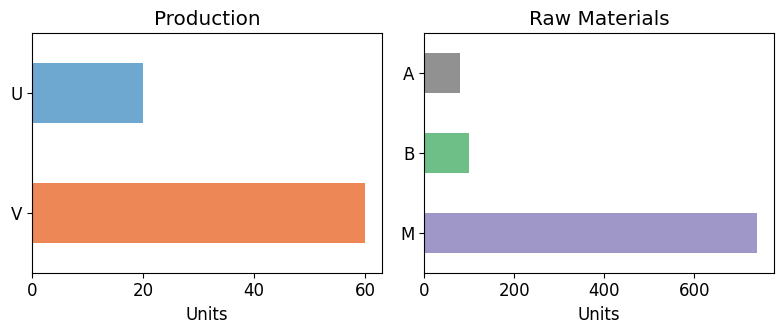

In [32]:
import matplotlib.pyplot as plt

# Create a 1x2 grid of subplots and configure global settings
fig, ax = plt.subplots(1, 2, figsize=(8, 3.5))
plt.rcParams["font.size"] = 12
colors = plt.cm.tab20c.colors
color_sets = [[colors[0], colors[4]], [colors[16], colors[8], colors[12]]]
datasets = [production, raw_materials]
titles = ["Production", "Raw Materials"]

# Plot data on subplots
for i, (data, title, color_set) in enumerate(zip(datasets, titles, color_sets)):
    data.plot(ax=ax[i], kind="barh", title=title, alpha=0.7, color=color_set)
    ax[i].set_xlabel("Units")
    ax[i].invert_yaxis()
plt.tight_layout()
plt.show()

Para descubrir funciones más avanzadas de Pyomo, consulte el [cuaderno siguiente](03-production-planning-advanced.ipynb).